Epoch 1, Loss: 0.5000, Accuracy: 83.70%
Epoch 2, Loss: 0.1182, Accuracy: 96.34%
Epoch 3, Loss: 0.0872, Accuracy: 97.30%
Epoch 4, Loss: 0.0673, Accuracy: 97.94%
Epoch 5, Loss: 0.0582, Accuracy: 98.27%

Độ chính xác trên tập test: 97.97%


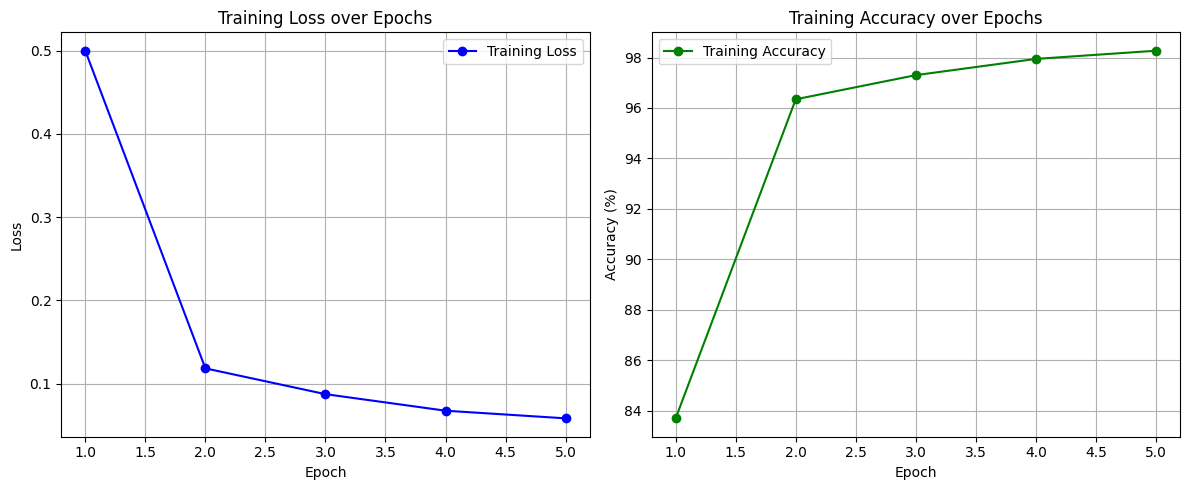

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# 1. Tải dữ liệu MNIST
transform = transforms.ToTensor()
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

# 2. Định nghĩa mô hình CNN với 3 tầng tích chập
class MNIST_CNN(nn.Module):
    def __init__(self):
        super(MNIST_CNN, self).__init__()
        # Tầng tích chập 1: 1 kênh đầu vào -> 16 kênh đầu ra, kernel 3x3
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)
        # Tầng tích chập 2: 16 kênh đầu vào -> 32 kênh đầu ra, kernel 3x3
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)
        # Tầng tích chập 3: 32 kênh đầu vào -> 64 kênh đầu ra, kernel 3x3 (THÊM MỚI)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=0)
        # Tầng pooling: vùng 2x2, giảm kích thước một nửa
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # Tầng fully connected: từ 64 * 1 * 1 = 64 -> 10 lớp (0-9)
        self.fc1 = nn.Linear(64 * 1 * 1, 10)  # ĐÃ SỬA

    def forward(self, x):
        # Conv1 (28x28 -> 26x26) -> ReLU -> Pool (26x26 -> 13x13)
        x = self.pool(torch.relu(self.conv1(x)))
        # Conv2 (13x13 -> 11x11) -> ReLU -> Pool (11x11 -> 5x5)
        x = self.pool(torch.relu(self.conv2(x)))
        # Conv3 (5x5 -> 3x3) -> ReLU -> Pool (3x3 -> 1x1) (THÊM MỚI)
        x = self.pool(torch.relu(self.conv3(x)))
        # Duỗi tensor thành vector (batch_size, 64*1*1 = 64)
        x = x.view(-1, 64 * 1 * 1)  # ĐÃ SỬA
        x = self.fc1(x)
        return x

# Khởi tạo mô hình, hàm mất mát và bộ tối ưu
model = MNIST_CNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# 3. Huấn luyện mô hình
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

loss_values = []
accuracy_values = []

for epoch in range(5):
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total
    loss_values.append(epoch_loss)
    accuracy_values.append(epoch_accuracy)
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")

# 4. Đánh giá mô hình trên tập test
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print(f"\nĐộ chính xác trên tập test: {100 * correct / total:.2f}%")

# 5. Vẽ biểu đồ Loss và Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, 6), loss_values, marker='o', color='b', label='Training Loss')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, 6), accuracy_values, marker='o', color='g', label='Training Accuracy')
plt.title('Training Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

## Giải thích câu 2: Thêm tầng tích chập thứ ba


### Tác dụng của việc thêm tầng tích chập

- **Học đặc trưng phức tạp hơn**:
  - Tầng `conv1` học các nét cơ bản (đường thẳng, góc).
  - Tầng `conv2` học các hình dạng đơn giản (vòng tròn, đường cong).
  - Tầng `conv3` học các đặc trưng trừu tượng hơn, kết hợp từ các đặc trưng trước đó để nhận diện chính xác hơn.

- **Giảm kích thước ảnh**:
  - Ảnh 28x28 → 13x13 → 5x5 → 1x1
  - Feature map cuối cùng chỉ còn 1x1 pixel nhưng có 64 kênh → giữ được nhiều thông tin ở dạng đặc trưng.

- **Tăng độ chính xác**:
  - Mô hình sâu hơn có thể phân biệt tốt hơn các số dễ nhầm.
  - Tuy nhiên, mức tăng không quá lớn vì MNIST là dataset đơn giản, mô hình 2 tầng đã đủ tốt.
